<div style="border:1px solid black; padding:10px 10px;">
    <strong>CIVIL-321 "Modélisation Numérique des Solides et Structures"</strong><br/><br/>
    <span style="text-decoration:underline;font-weight:bold;">Comment utiliser ce Jupyter Notebook?
    </span><br/><br/>
    Ce <strong>Notebook</strong> est constitué de cellules de texte et de cellule de code. Les cellules de codes doivent être  <strong>executées</strong> pour voir le résultat du programme. Certaines cellules doivent être remplies par vos soins. Pour exécuter une cellule, cliquez dessus simplement et ensuite cliquez sur le bouton "play" (<span style="font: bold 12px/30px Arial, serif;">&#9658;</span>) dans la barre de menu au dessus du notebook. Vous pouvez aussi taper la combinaison de touches <code>shift + enter</code>. Il est important d'éxécuter les cellules de code en respectant leur ordre d'arrivée dans le notebook.
</div>

On vous encourage à poser vos questions et donner votre feedback sur ce notebook sur la plateforme ED Discussion du cours accessible en cliquant sur ce bouton:
 
 
 
<div class="container" >
        <a href="https://edstem.org/eu/courses/409/discussion?category=Exercices">
            <button class="btn btn-primary btn-lg">Ed Discussion</button>
        </a>
</div>

In [1]:
from utils import *

# Série d'exercices : Minimization de l'énergie potentielle

Considérons le barreau uni-dimensionnel élastique linéaire de la figure ci dessous. Les efforts volumiques sont négligés. Le barreau est modélisé avec un élément à trois noeuds.

![](Figures/ex4.svg)

Supposons une évolution polynomiale du champ de déplacement~$u$ sous la forme suivante:
  
$$u^h(x) = a_1 + a_2 x + a_3 x^2$$

 1. Quelles sont les conditions sur $a_1$, $a_2$ et $a_3$ pour que $u^h$ satisfasse les conditions limites?

SolutionToRemove

Déterminons les constantes de ce polynôme à partir des conditions aux limites.

$$    \begin{align*}
      u^h(x=0) = 0 &\Rightarrow a_1 = 0 \\
      u^h(x=L) = 0 &\Rightarrow a_2 = - 2 a_3
    \end{align*}
$$

 2. Écrire l'énergie potentielle totale du système en fonction de $a_1$, $a_2$ et $a_3$. Rappel de l'expression de l'énergie potentielle pour une barre:
    
    $$\Pi = \frac{1}{2}\int_0^L{EA\left(\frac{\text{d}u}{\text{d}x}\right)^2\,\text{d}x} - Fu_{L/2}$$

SolutionToRemove

L'approximation polynomiale peut donc être exprimées seulement en
    fonction de la constante~$a_3$ :

$$\begin{equation*}
u^h = a_3 \left( -2x + x^2 \right).
\end{equation*}$$

On peut interpréter~$a_3$ comme le déplacement en $x=L/2$ : $u^h(x=L/2) = u_{L/2} = -a_3$

On peut alors exprimer la dérivée du déplacement approchée $u^h(x)$
en fonction de l'abscisse~$x$,

$$\begin{equation*}
\frac{du^h}{dx} = 2 a_3 \left( -1 + x \right).
\end{equation*}$$

En injectant cette expression dans l'énergie potentielle totale
définie précédemment, on obtient un polynôme en $a_3$

$$\begin{equation*}
\Pi = \frac{1}{2} \int_0^2 4 {a_3}^2 \left( -1 + x\right)^2 dx + 2 a_3 = \frac{4 {a_3}^2}{3} + 2 a_3
\end{equation*}$$

 3. Déterminer $u^h(x)$ qui minimise l'énergie potentielle totale du système (trouver les valeurs des constantes $a_i$).

SolutionToRemove

La valeur de la constante $a_3$ peut être obtenue par la minimisation de cette expression

$$\begin{equation*}
\frac{\partial \Pi}{\partial a_3} = \frac{8 a_3}{3} + 2 = 0
\end{equation*}$$

Le déplacement approché $u_h$ est donc de la forme

$$\begin{equation*}
u^h = \frac{3}{4} \left( 2x - x^2 \right).
\end{equation*}$$

On peut en déduire l'expression de la contrainte dans la barre en
utilisant

$$\begin{equation*}
\sigma^h = E\frac{du^h}{dx} = \frac{3}{2} \left( 1 - x \right).
\end{equation*}$$

4. Déterminer la solution exacte et la comparer à la solution polynomiale approchée.

SolutionToRemove

Le diagramme des efforts normaux dans la barre est présenté ci-dessous:

![](Figures/ex4-1.svg)

Le déplacement exact s'écrit:

$$\begin{equation*}
u(x) = \int\frac{N(x)}{EA}\,\text{d}x
\end{equation*}$$

$$u(x) =
  \begin{cases}
    \int 1\,\text{d}x = x + C_1 &\quad 0 \le x \le 1\\
    \int -1\,\text{d}x = -x + C_2 &\quad 1 \le x \le 2
  \end{cases}
$$

On utilise les conditions limites pour trouver les constantes $C_1$ et $C_2$:

$$\begin{eqnarray*}
    u(0) = 0 & \Rightarrow & C_1 = 0\\
    u(2) = 0 & \Rightarrow & C_2 = 2
  \end{eqnarray*}$$
  
La comparaison avec les solutions exactes est représentée sur les courbes ci-dessous:

![](Figures/ex4-2.svg) ![](Figures/ex4-3.svg)

<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mp/fsb59mzj0gdgkk1rsc12xrpw0000gn/T/ipykernel_3905/535037743.py:29: SyntaxWarning: invalid escape sequence '\s'
  plt.title('$\sigma$(x)')


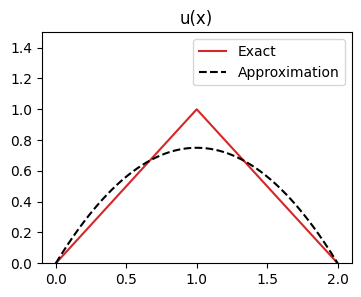

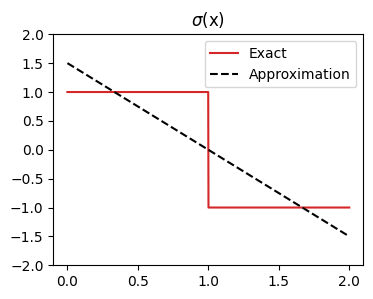

In [2]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0,2,1000)

def exact(x):
    return np.where(x <= 1, x, 2-x)

def approx(x):
    return 3/4 * (2*x - x**2)

plt.figure(figsize=(4,3))
plt.plot(x, exact(x), color='tab:red', label='Exact')
plt.plot(x, approx(x), color='black', linestyle='--', label='Approximation')
plt.title('u(x)')
plt.ylim(0,1.5)
plt.legend()
plt.show()

def exact(x):
    return np.where(x <= 1, 1, -1)

def approx(x):
    return 3/2 * (1-x)

plt.figure(figsize=(4,3))
plt.plot(x, exact(x), color='tab:red', label='Exact')
plt.plot(x, approx(x), color='black', linestyle='--', label='Approximation')
plt.title('$\sigma$(x)')
plt.ylim(-2, 2)
plt.legend()
plt.show()

Discrétisons le domaine en deux parties égales (compatibles avec le chargement), et utilisons l'approximation polynomiale par morceaux définie comme suit (le barreau est maintenant modélisé avec deux éléments qui ont chacun deux noeuds). Notez que le champ $u^h$ doit être continu à $x = \frac{L}{2}$.

$$u^h(x) =
  \begin{cases}
    a_1 + a_2 x  \quad 0 \le x \le L/2\\
    a_3 + a_4 x  \quad L/2 \le x \le L
  \end{cases}
$$

5. Identifier les valeurs de $a_1$, $a_2$, $a_3$ et $a_4$ qui minimisent l'énergie potentielle, satisfont les conditions limites et la condition de continuité, puis comparer avec la solution exacte.

SolutionToRemove

Appliquons la même démarche. D'abord, identifions les constantes à
partir des conditions aux limites

$$\begin{align*}
      u^h(x=0) = 0 &\Rightarrow a_1 = 0 \\
      u^h(x=L) = 0 &\Rightarrow a_3 = -2 a_4 \\
      u^h(x=L/2) = u_{L/2} &\Rightarrow u_{L/2} = a_1 + a_2 = a_2 \\
      &\Rightarrow u_{L/2} = a_3 + a_4 = -a_4
\end{align*}$$

À partir des ces trois équations, le polynôme peut être écrit en
fonction d'une inconnue. Nous pouvons par exemple choisir de
l'écrire en fonction de~$a_4$

$$\begin{align*}
      u^h(x) = \left\{
      \begin{array}{lr}
        -a_4 x  &: 0 \le x \le L/2\\
        -2 a_4 + a_4 x &: L/2 \le x \le L
      \end{array}
      \right.
    \end{align*}$$
    
La dérivée sera de la forme

$$\begin{align*}
      \frac{du^h(x)}{dx} = \left\{
      \begin{array}{lr}
        -a_4 &: 0 \le x < L/2\\
        a_4  &: L/2 < x \le L
      \end{array}
      \right.
    \end{align*}$$
    
L'énergie potentielle est donc

$$\begin{equation*}
      \Pi = \frac{1}{2} \left[ \int_0^1 {a_4}^2  dx +
        \int_1^2 {a_4}^2 dx \right] + 2 a_4 = {a_4}^2 + 2 a_4.
    \end{equation*}$$

On peut identifier $a_4$ en minimisant cette énergie potentielle totale:

$$\begin{equation*}
      \frac{\partial \Pi}{\partial a_4} = 2a_4 + 2 = 0 \Rightarrow a_4 = -1
    \end{equation*}$$

Ce qui nous donne

$$\begin{align*}
        u^h(x) = \left\{
        \begin{array}{lr}
          x  &: 0 \le x \le 1\\
          2 - x &: 1 \le x \le 2
        \end{array}
        \right.
      \end{align*}$$
$$\begin{align*}
        \sigma^h(x) = E\frac{du^h}{dx} = \left\{
        \begin{array}{lr}
          1  &: 0 \le x < 1\\
          -1 &: 1 < x \le 2
        \end{array}
        \right.
      \end{align*}$$
      
Comme illustré ci dessous, dans ce cas spécifique, l'approximation
polynomiale par morceau permet d'obtenir la solution exacte.

![](Figures/ex4-4.svg) ![](Figures/ex4-5.svg)
